# Tutorial: the SAXS simulation model

This notebook illustrates the physical SAXS forward model in `aisaxs/physical_models/lnp_model.py`. The model treats a lipid nanoparticle as a spherical particle of radius `R` with a homogeneous shell of thickness `d` and contrast `relative_rho_shell`, and a stochastic interior described by a Gaussian random field (GRF) whose two-component log-normal power spectrum is controlled by `(w_q, m_q, s_q)` and an overall density shift `GRF_shift`.

We will:

1. Build the simulation context (computational grids, FFT kernels, radial weights).
2. Generate a single monodisperse SAXS curve and plot it.
3. Show how varying the shell thickness changes the curve.
4. Generate a polydisperse curve by Monte Carlo averaging over a truncated normal radius distribution.

**Next:** [`tutorial_ml_surrogate.ipynb`](tutorial_ml_surrogate.ipynb) shows the neural surrogate that replaces this simulator at fitting time.

In [1]:
# Make the repo root importable so `aisaxs` resolves whether this
# notebook is launched from the repo root or from `notebooks/`.
import sys
from pathlib import Path
ROOT = Path.cwd() if (Path.cwd() / 'aisaxs').is_dir() else Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from aisaxs.physical_models.lnp_model import (
    build_saxs_simulation_context,
    saxs_kernel_one,
    synthetic_polydisperse_mc_mean_and_examples,
)

## 1. Build the simulation context

The context holds everything that depends only on the grid: the real-space 3D grid, the q-grid, FFT helper kernels, and sparse weights for the radial average. Build it once and reuse it across many forward-model calls.

In [2]:
ctx = build_saxs_simulation_context(q_min=0.001, q_max=0.2, n_q=300)
q_grid = np.asarray(ctx["q_grid"])
print(f"q grid: {q_grid.shape[0]} points from {q_grid[0]:.4f} to {q_grid[-1]:.4f} A^-1")

E0519 08:25:39.977632  867793 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)
E0519 08:25:39.986444  867696 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)


q grid: 300 points from 0.0010 to 0.2000 A^-1


## 2. A monodisperse SAXS curve

Pick one parameter set and call the forward model. Internally it draws several GRF realisations and averages their scattering intensities.

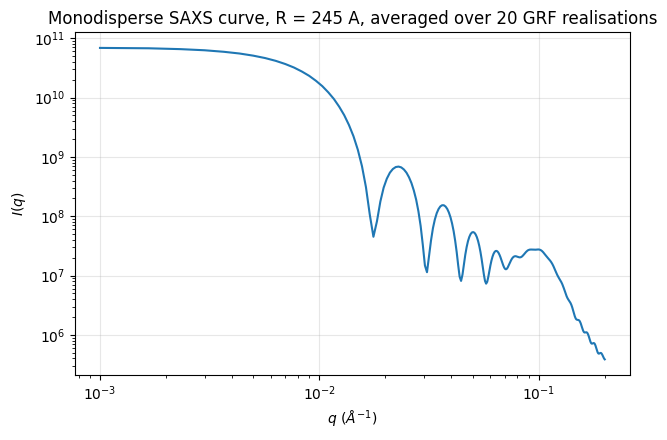

In [4]:
I = saxs_kernel_one(
    w_q=jnp.array([0.7, 0.3]),
    m_q=jnp.array([0.10, 0.11]),
    s_q=jnp.array([0.015, 0.10]),
    R=245.0,
    rho_solvent=1.0,
    shell_thickness=60.0,
    GRF_shift=-0.1,
    relative_rho_shell=0.96,
    context=ctx,
    n_cores=20,
)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.loglog(q_grid, np.asarray(I))
ax.set_xlabel(r"$q$ ($\AA^{-1}$)")
ax.set_ylabel(r"$I(q)$")
ax.set_title("Monodisperse SAXS curve, R = 245 A, averaged over 20 GRF realisations")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Sensitivity to shell thickness

The shell modulates the curve at q ~ pi/d. Increasing the shell thickness `d` shifts that modulation toward smaller q.

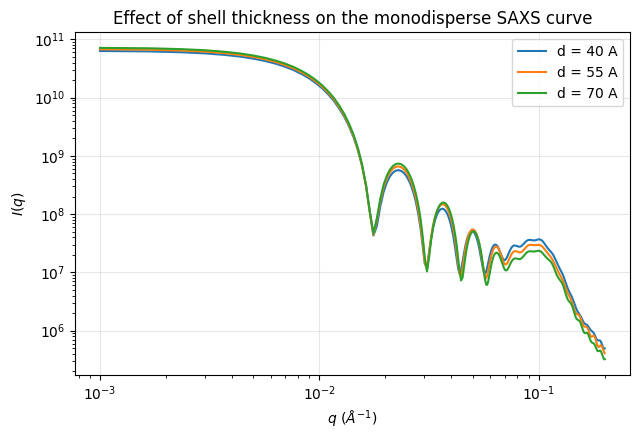

In [5]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
for d in [40.0, 55.0, 70.0]:
    I_d = saxs_kernel_one(
        w_q=jnp.array([0.7, 0.3]),
        m_q=jnp.array([0.10, 0.11]),
        s_q=jnp.array([0.015, 0.10]),
        R=245.0,
        rho_solvent=1.0,
        shell_thickness=d,
        GRF_shift=-0.1,
        relative_rho_shell=0.96,
        context=ctx,
        n_cores=20,
    )
    ax.loglog(q_grid, np.asarray(I_d), label=f"d = {d:.0f} A")
ax.set_xlabel(r"$q$ ($\AA^{-1}$)")
ax.set_ylabel(r"$I(q)$")
ax.set_title("Effect of shell thickness on the monodisperse SAXS curve")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Polydispersity via Monte Carlo averaging

Real samples are not monodisperse. We average the forward model over a truncated normal distribution of radii, drawing a fresh GRF realisation for each particle. Here we sample 100 particles.

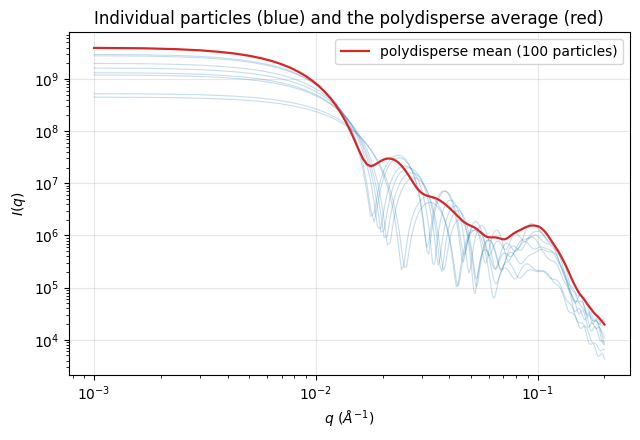

In [6]:
key = jax.random.PRNGKey(0)

I_poly, I_examples, R_examples = synthetic_polydisperse_mc_mean_and_examples(
    key,
    w_q=jnp.array([0.7, 0.3]),
    m_q=jnp.array([0.10, 0.11]),
    s_q=jnp.array([0.015, 0.10]),
    rho_solvent=1.0,
    shell_thickness=60.0,
    GRF_shift=-0.1,
    relative_rho_shell=0.96,
    context=ctx,
    mu_R=245.0,
    sigma_R=30.0,
    R_lo=100.0,
    R_hi=500.0,
    n_particles=100,
    n_store=8,
)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
for i in range(int(I_examples.shape[0])):
    ax.loglog(q_grid, np.asarray(I_examples[i]), color="tab:blue", alpha=0.25, linewidth=0.8)
ax.loglog(q_grid, np.asarray(I_poly), color="tab:red", linewidth=1.6, label="polydisperse mean (100 particles)")
ax.set_xlabel(r"$q$ ($\AA^{-1}$)")
ax.set_ylabel(r"$I(q)$")
ax.set_title("Individual particles (blue) and the polydisperse average (red)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

We generated monodisperse SAXS curves from a single parameter set, showed how the shell thickness modulates the curve, and integrated over a distribution of radii to obtain a polydisperse mean. The polydisperse average is the quantity actually measured by SAXS on a real LNP sample.

The fitting scripts in this repository invert this mapping: given an experimental curve, they find the parameter ranges (including the radius distribution) that reproduce it. Because the physical simulation is slow, those scripts use a trained neural surrogate of the monodisperse forward map. See [`tutorial_ml_surrogate.ipynb`](tutorial_ml_surrogate.ipynb) for the surrogate side.